<a href="https://colab.research.google.com/github/wagaya1935/voice-analysis/blob/main/%E9%9F%B3%E5%A3%B0%E8%A7%A3%E6%9E%90_%E6%AF%94%E8%BC%83.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.データの取得

今回、「Cevio AI」のOИE(オネ)と「UTAU」の重音テトを使用して、DECO*27さんの[モニタリング(Best Friend Remix) feat. 初音ミク]のサビ部分をカバーした音声を作成して解析した。

モニタリング(Best Friend Remix) feat. 初音ミク:URL(https://www.youtube.com/watch?v=C-CYwNz3z8w)

このとき、作成したonesong.wavとtetosongをcsvファイルに変換して用いた。

データ形式の違い(サンプリング周波数)

録音する環境が違うため、それぞれが一番自然な周波数に設定している。

まず、必要なライブラリのインストールとインポートを行う。

In [ ]:
!pip install japanize_matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from pydub import AudioSegment
import scipy.signal as sp

次に、データファイルを読み込む。

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = '/content/drive/MyDrive/Voiceフォルダ/'

In [ ]:
file_one = "onesong.wav"
file_teto = "tetosong.wav"

In [ ]:
ONE = AudioSegment.from_wav(path + file_one)
ONE

In [ ]:
TETO = AudioSegment.from_wav(path + file_teto)
TETO

データをcsvに経由して配列に格納する。

In [ ]:
#処理を関数化(2つのファイルを同じ手順で処理するため)
def process_audio_file(filename):
  sounds = AudioSegment.from_wav(path + filename)
  y = np.array(sounds.get_array_of_samples()[::sounds.channels])

  N = len(y)
  t = np.linspace(0, sounds.duration_seconds, N, endpoint=False)

  data_dict = {'Time': t, 'Amplitude': y}
  df = pd.DataFrame(data_dict)
  csv_name = filename.replace('.wav', '.csv')
  df.to_csv(path + csv_name, index=False)

  data_loaded = pd.read_csv(path + csv_name)
  return data_loaded['Time'].values, data_loaded['Amplitude'].values, sounds.frame_rate

In [ ]:
t_one, y_one, fs_one = process_audio_file(file_one)
t_teto, y_teto, fs_teto = process_audio_file(file_teto)

データの確認を行う。

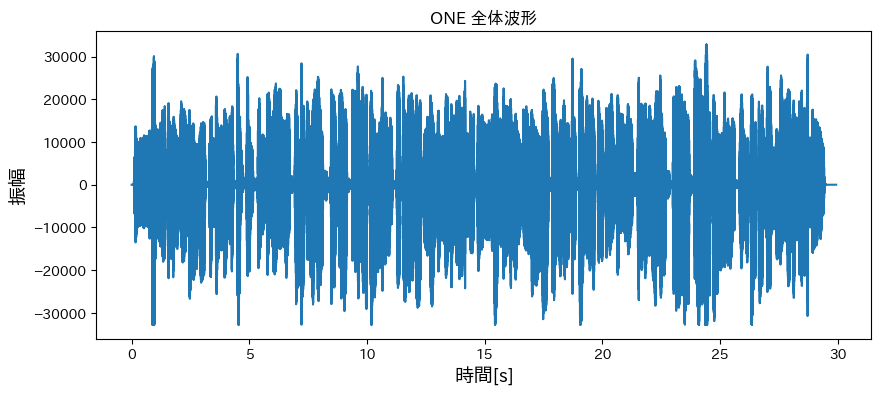

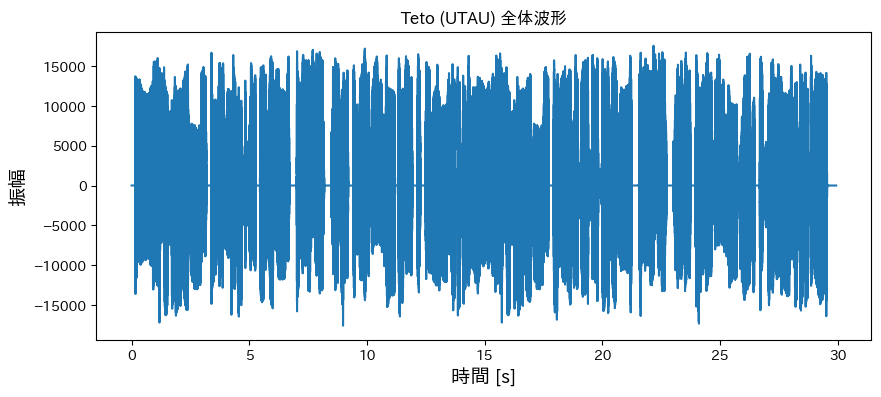

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(t_one, y_one)
plt.title('ONE 全体波形')
plt.xlabel('時間[s]', fontsize=14)
plt.ylabel('振幅', fontsize=14)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t_teto, y_teto)
plt.title('Teto (UTAU) 全体波形')
plt.xlabel('時間 [s]', fontsize=14)
plt.ylabel('振幅', fontsize=14)
plt.show()

2,解析パラメータを決める。

In [ ]:
print('ONE サンプリング周波数:', fs_one, 'Hz')
print('TETO サンプリング周波数:', fs_teto, 'Hz')

ONE サンプリング周波数: 48000 Hz
TETO サンプリング周波数: 44100 Hz


周波数分解能が23Hz以下になるのに必要なデータ数を求める。

In [ ]:
Df_limit = 23

N_req = fs_one / Df_limit
n = int(np.log2(N_req)) + 1
N = 2**n

Df_one = fs_one / N
Df_teto = fs_teto / N

print('データ数 N:', N)
print(f'周波数分解能 (ONE)', Df_one, 'Hz')
print(f'周波数分解能 (TETO)', Df_teto, 'Hz')

データ数 N: 4096
周波数分解能 (ONE) 11.71875 Hz
周波数分解能 (TETO) 10.7666015625 Hz


In [ ]:
fn_one = fs_one / 2
fn_teto = fs_teto / 2
print(f'ナイキスト周波数: ONE={fn_one}Hz, TETO={fn_teto}Hz')

ナイキスト周波数: ONE=24000.0Hz, TETO=22050.0Hz


In [ ]:
Tw_one = N / fs_one
Tw_teto = N / fs_teto
print(f'ウィンドウ幅: ONE={Tw_one}s, TETO={Tw_teto}s')

ウィンドウ幅: ONE=0.08533333333333333s, TETO=0.09287981859410431s


時間窓を、比較しやすい箇所から切り出す。

In [ ]:
start_index_one = 40000
start_index_teto = 40000

In [ ]:
t_w_one = y_one[start_index_one : start_index_one + N]
y_w_one = y_one[start_index_one : start_index_one + N]

In [ ]:
t_w_teto = y_teto[start_index_teto : start_index_teto + N]
y_w_teto = y_teto[start_index_teto : start_index_teto + N]

In [ ]:
if np.max(np.abs(y_w_one)) != 0:
    y_w_one = y_w_one / np.max(np.abs(y_w_one))

if np.max(np.abs(y_w_teto)) != 0:
    y_w_teto = y_w_teto / np.max(np.abs(y_w_teto))

In [ ]:
t_plot_one = np.arange(N) / fs_one
t_plot_teto = np.arange(N) / fs_teto

波形の形状の比較

ONE:波形の形が周期ごとに微妙に変化し続けている。

TETO:母音の伸ばし部分などで、似た形状の波形が規則正しく繰り返される傾向がある。

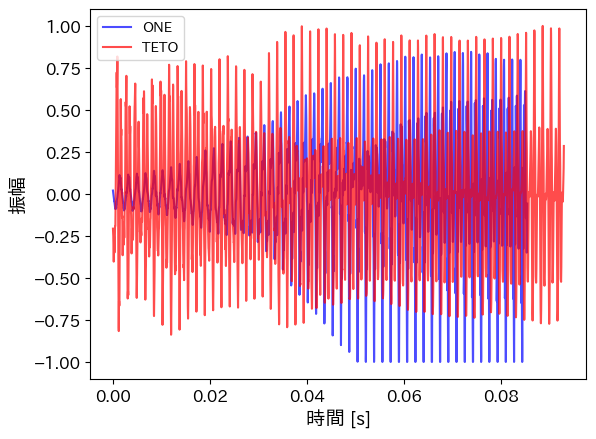

In [ ]:
plt.plot(t_plot_one, y_w_one, color='blue', alpha=0.7, label='ONE')
plt.plot(t_plot_teto, y_w_teto, color='red', alpha=0.7, label='TETO')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('時間 [s]', fontsize=14)
plt.ylabel('振幅', fontsize=14)
plt.legend()
plt.show()

3. フーリエ変換を行う。

以下の関数で周波数の配列を取得する。

In [ ]:
fq_one = np.fft.fftfreq(N, d=1/fs_one)
fq_teto = np.fft.fftfreq(N, d=1/fs_teto)
print('周波数の配列', fq_one)
print('周波数の配列', fq_teto)

周波数の配列 [  0.       11.71875  23.4375  ... -35.15625 -23.4375  -11.71875]
周波数の配列 [  0.          10.76660156  21.53320312 ... -32.29980469 -21.53320312
 -10.76660156]


FFTを行う。

In [ ]:
y_fft_one = np.fft.fft(y_w_one)
y_fft_teto = np.fft.fft(y_w_teto)

複素数であるため、絶対値を計算する。

In [ ]:
y_fft_abs_one = np.abs(y_fft_one)
y_fft_abs_teto = np.abs(y_fft_teto)

振幅を正規化するため、データをN / 2で割る。

In [ ]:
y_fft_amp_one = y_fft_abs_one / N * 2
y_fft_amp_teto = y_fft_abs_teto / N * 2

左右対称となっているため、配列の前半を抽出する。

In [ ]:
fq_p_one = fq_one[:int(N/2)]
y_fft_amp_p_one = y_fft_amp_one[:int(N/2)]

In [ ]:
fq_p_teto = fq_teto[:int(N/2)]
y_fft_amp_p_teto = y_fft_amp_teto[:int(N/2)]

図で確認する。

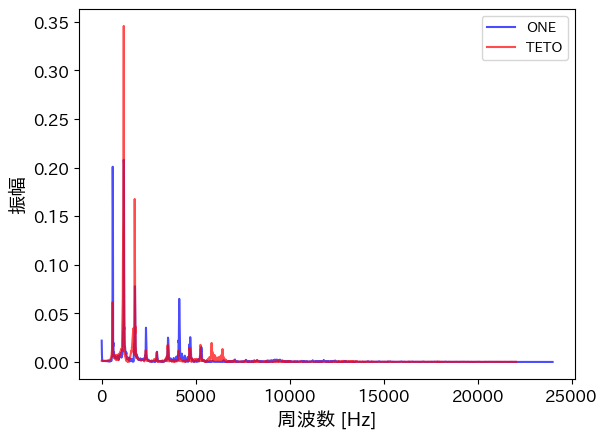

In [ ]:
plt.plot(fq_p_one, y_fft_amp_p_one, color='blue', alpha=0.7, label='ONE')
plt.plot(fq_p_teto, y_fft_amp_p_teto, color='red', alpha=0.7, label='TETO')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('周波数 [Hz]', fontsize=14)
plt.ylabel('振幅', fontsize=14)
plt.legend()
plt.show()

拡大表示する。

周波数スペクトルの比較

ONE:低音（基音）から高音（倍音）にかけて、山（ピーク）の高さが滑らかな曲線を描いて減衰していく傾向がある。

TETO:特定の周波数の山だけが強かったり、並び方がギザギザしたりする、ピークが見られることがある。

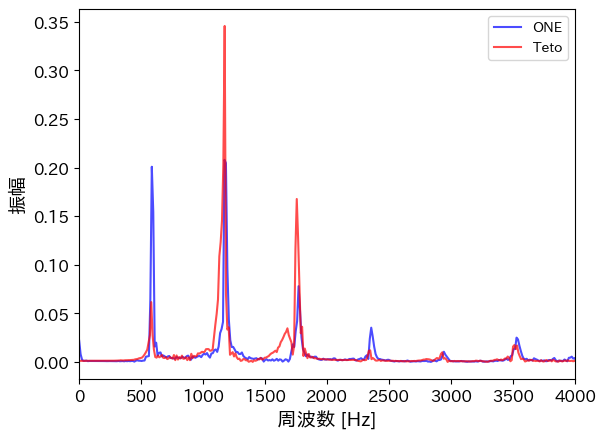

In [ ]:
plt.plot(fq_p_one, y_fft_amp_p_one, color='blue', alpha=0.7, label='ONE')
plt.plot(fq_p_teto, y_fft_amp_p_teto, color='red', alpha=0.7, label='Teto')
plt.xlim(0, 4000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('周波数 [Hz]', fontsize=14)
plt.ylabel('振幅', fontsize=14)
plt.legend()
plt.show()

4. 短時間フーリエ解析を行う。

In [ ]:
f_stft_one, t_stft_one, i_stft_one = sp.stft(y_one, fs=fs_one, nperseg=N)
f_stft_teto, t_stft_teto, i_stft_teto = sp.stft(y_teto, fs=fs_teto, nperseg=N)

スペクトログラムの比較

ONE:音程を表す横線が、滑らかな曲線でつながっている。

TETO:音程の線が直線的であったり、音の切り替わり目でカクっと階段状に見えたりすることがある。

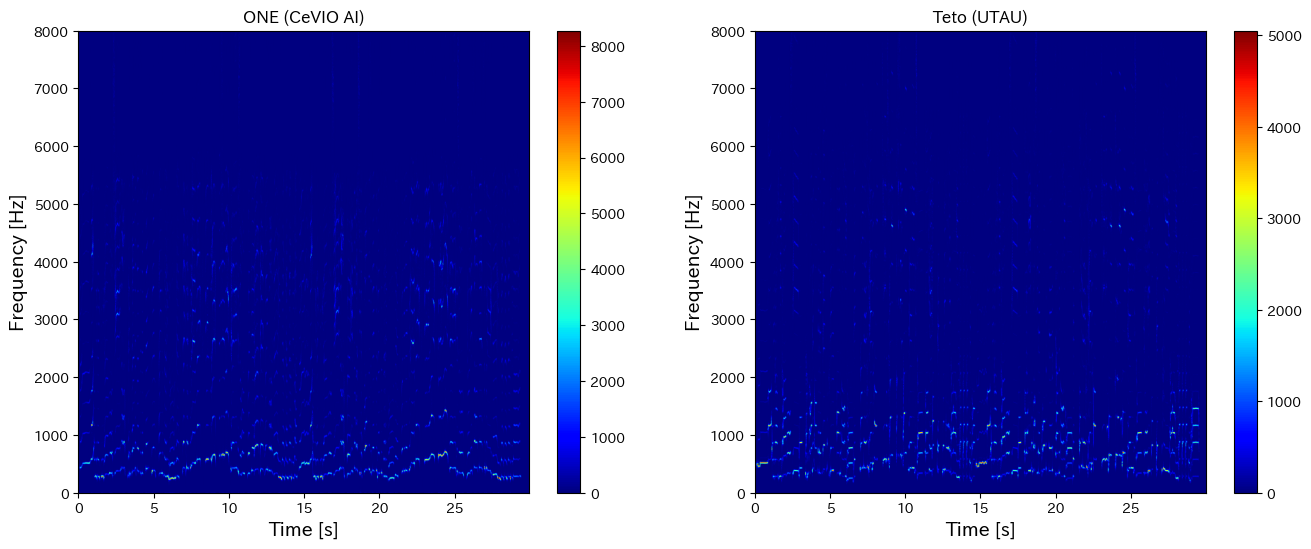

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# ONE
mesh1 = axes[0].pcolormesh(t_stft_one, f_stft_one, np.abs(i_stft_one), cmap='jet', shading='gouraud')
axes[0].set_title('ONE (CeVIO AI)')
axes[0].set_xlabel('Time [s]', fontsize=14)
axes[0].set_ylabel('Frequency [Hz]', fontsize=14)
axes[0].set_ylim(0, 8000)
fig.colorbar(mesh1, ax=axes[0])

# Teto
mesh2 = axes[1].pcolormesh(t_stft_teto, f_stft_teto, np.abs(i_stft_teto), cmap='jet', shading='gouraud')
axes[1].set_title('Teto (UTAU)')
axes[1].set_xlabel('Time [s]', fontsize=14)
axes[1].set_ylabel('Frequency [Hz]', fontsize=14)
axes[1].set_ylim(0, 8000)
fig.colorbar(mesh2, ax=axes[1])

plt.show()

5. 逆フーリエ変換を行う。

In [ ]:
y_ift_one = np.fft.ifft(y_fft_one)
y_ift_teto = np.fft.ifft(y_fft_teto)

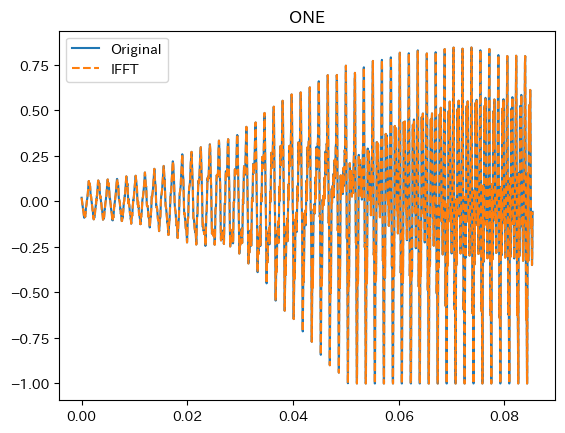

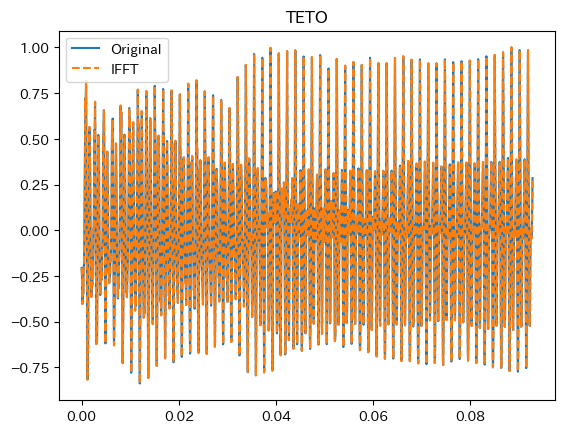

In [ ]:
plt.plot(t_plot_one, y_w_one, label='Original')
plt.plot(t_plot_one, y_ift_one.real, linestyle='--', label='IFFT')
plt.title('ONE')
plt.legend()
plt.show()

plt.plot(t_plot_teto, y_w_teto, label='Original')
plt.plot(t_plot_teto, y_ift_teto.real, linestyle='--', label='IFFT')
plt.title('TETO')
plt.legend()
plt.show()

まとめ

AI音声合成であるONEは、波形の非周期性やスペクトルの滑らかな減衰といった『人間らしい揺らぎ』を再現していることが確認できた。対して、サンプリング方式である重音テトは、波形の高い規則性や特徴的なスペクトル形状といった『録音音声のループ再生』に基づく機械的な特徴が確認できた。